In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re, json, os, pickle
warnings.filterwarnings('ignore')

import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

for r in ['punkt','punkt_tab','stopwords']:
    try: nltk.data.find(f'tokenizers/{r}' if 'punkt' in r else f'corpora/{r}')
    except: nltk.download(r, quiet=True)

severity_names = {1:'No Explicit Reproach', 2:'Disapproval', 3:'Accusation', 4:'Blame'}
print('Library berhasil dimuat.')


Library berhasil dimuat.


# **1. DATA PREPARATION**

In [2]:
# Membaca data yang sudah dilabeli
data = pd.read_csv('../dataset/data_pesan_telekomunikasi_opus4.6.csv')

# Hapus severity 0 (Non-Keluhan)
data = data[data['severity'] > 0].reset_index(drop=True)
data.rename(columns={'text': 'message'}, inplace=True)

print(f'Total data keluhan: {len(data):,}')
print(data['severity'].value_counts().sort_index())


Total data keluhan: 54,496
severity
1     4711
2    36628
3     8669
4     4488
Name: count, dtype: int64


In [3]:
# Balanced Sampling: internal SEMUA masuk, tambah dari playstore
TARGET = 4000

balanced_dfs = []
for label in sorted(data['severity'].unique()):
    subset = data[data['severity'] == label]
    if 'source' in data.columns:
        internal = subset[subset['source'] == 'internal']
        playstore = subset[subset['source'] == 'playstore']
    else:
        internal = subset
        playstore = pd.DataFrame()
    
    # Internal SEMUA masuk dulu
    sampled = internal.copy()
    sisa = TARGET - len(sampled)
    if sisa > 0 and len(playstore) > 0:
        tambahan = resample(playstore, n_samples=min(sisa, len(playstore)),
                           random_state=42, replace=False)
        sampled = pd.concat([sampled, tambahan], ignore_index=True)
    if len(sampled) < TARGET:
        sampled = resample(sampled, n_samples=TARGET, random_state=42, replace=True)
    balanced_dfs.append(sampled)
    print(f'  Level {label}: internal={len(internal):,}, playstore={len(playstore):,} -> {len(sampled):,}')

data = pd.concat(balanced_dfs, ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
print(f'\nTotal balanced: {len(data):,}')
print(data['severity'].value_counts().sort_index())


  Level 1: internal=2,487, playstore=2,224 -> 4,000
  Level 2: internal=3,983, playstore=32,645 -> 4,000
  Level 3: internal=86, playstore=8,583 -> 4,000
  Level 4: internal=156, playstore=4,332 -> 4,000

Total balanced: 16,000
severity
1    4000
2    4000
3    4000
4    4000
Name: count, dtype: int64


# **2. DATA CLEANING**

In [4]:
# Mengecek jumlah nilai yang kosong (NULL/NaN) di tiap kolom
print("Pengecekan missing values:")
print(data.isna().sum())

# Menghapus baris null dan duplikat
total = data.shape[0]
data.dropna(subset=['message'], inplace=True)
a = data.shape[0]
data.drop_duplicates(subset=['message'], inplace=True)

data.reset_index(drop=True, inplace=True)
print(f'\nSebelum: {total:,} | Hapus null: {total-a} | Hapus duplikat: {a-data.shape[0]}')
print(f'Total data bersih: {data.shape[0]:,}')


Pengecekan missing values:
message     0
source      0
severity    0
dtype: int64

Sebelum: 16,000 | Hapus null: 0 | Hapus duplikat: 0
Total data bersih: 16,000


# **3. TEXT PREPROCESSING**

In [5]:
## 1. CLEANING TEXT ##
def clean_text(df, text_field, new_field):
    df[new_field] = df[text_field].apply(lambda x: str(x))
    # Hapus HTML tag (<br>, <p>, dll)
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'<.*?>', ' ', x))
    # Hapus URL
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'https?://\S+|www\.\S+', ' ', x))
    # Hapus email (user@domain.com)
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'\S+@\S+\.\S+', ' ', x))
    # Hapus @mention dan #hashtag
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'(@|#)[A-Za-z0-9_]+', ' ', x))
    # Hapus 'RT' (retweet marker)
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'\bRT\b', ' ', x))
    # Hapus emoji dan karakter Unicode non-ASCII
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'[^\x00-\x7F]+', ' ', x))
    # Hapus angka
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'\d+', ' ', x))
    # Hapus tanda baca dan karakter khusus
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'[^A-Za-z \t]', ' ', x))
    # Hapus karakter berulang >2x (misal: 'baguuuus' -> 'bagus')
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'(.)\\1{2,}', r'\\1', x))
    # Hapus spasi berlebih
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'\s+', ' ', x).strip())
    # Hapus teks terlalu pendek (< 2 karakter)
    df[new_field] = df[new_field].apply(
        lambda x: x if len(x.strip()) >= 2 else '')
    return df

data = clean_text(data, 'message', 'cleaning_text')
data[['message','cleaning_text']].head()


,message,cleaning_text
0,Keluhan nya sama semua lemot dan ga bisa daily...,Keluhan nya sama semua lemot dan ga bisa daily...
1,Engga kok kak dulu itu masalahnya di range nya...,Engga kok kak dulu itu masalahnya di range nya...
2,kok aku buka gabisa ya,kok aku buka gabisa ya
3,kak apa ini punya teknisi nya naratel ya?,kak apa ini punya teknisi nya naratel ya
4,"Aplikasi busuk, tiba-tiba logout sendiri mau l...",Aplikasi busuk tiba tiba logout sendiri mau lo...


***CASE FOLDING***: Pengkonversian huruf menggunakan format huruf kecil seragam

In [6]:
## 2. CASE FOLDING ##
data['case_folding'] = data['cleaning_text'].str.lower()  # ubah semua huruf jadi lowercase
data[['cleaning_text', 'case_folding']].head()


,cleaning_text,case_folding
0,Keluhan nya sama semua lemot dan ga bisa daily...,keluhan nya sama semua lemot dan ga bisa daily...
1,Engga kok kak dulu itu masalahnya di range nya...,engga kok kak dulu itu masalahnya di range nya...
2,kok aku buka gabisa ya,kok aku buka gabisa ya
3,kak apa ini punya teknisi nya naratel ya,kak apa ini punya teknisi nya naratel ya
4,Aplikasi busuk tiba tiba logout sendiri mau lo...,aplikasi busuk tiba tiba logout sendiri mau lo...


***TOKENIZING***: Pemecahan kalimat menjadi potongan kata tunggal atau token

In [7]:
## 3. TOKENIZING ##
# Pecah kalimat menjadi token (kata tunggal) menggunakan NLTK
data['tokenizing'] = data['case_folding'].apply(word_tokenize)
data[['case_folding','tokenizing']].head()


,case_folding,tokenizing
0,keluhan nya sama semua lemot dan ga bisa daily...,"[keluhan, nya, sama, semua, lemot, dan, ga, bi..."
1,engga kok kak dulu itu masalahnya di range nya...,"[engga, kok, kak, dulu, itu, masalahnya, di, r..."
2,kok aku buka gabisa ya,"[kok, aku, buka, gabisa, ya]"
3,kak apa ini punya teknisi nya naratel ya,"[kak, apa, ini, punya, teknisi, nya, naratel, ya]"
4,aplikasi busuk tiba tiba logout sendiri mau lo...,"[aplikasi, busuk, tiba, tiba, logout, sendiri,..."


***NORMALISASI***: Perbaikan penulisan kata slang menjadi standard EYD (Ejaan)

In [8]:
## 4. NORMALISASI (Slang Words / Non-Standard) ##
# Load kamus slang dari file .txt (format JSON)
def load_norm_dict(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return json.load(f)  # parse JSON ke dictionary
    except:
        return {}

# Menggunakan kamus normalisasi combined_slang_words.txt
norm_dict = load_norm_dict('../dataset/combined_slang_words.txt')

# Ganti kata slang ke kata baku berdasarkan kamus
def normalize_tokens(tokens):
    return [norm_dict.get(t, t) for t in tokens]  # jika ada di kamus -> ganti, jika tidak -> tetap

data['normalized'] = data['tokenizing'].apply(normalize_tokens)
print(f'Kamus normalisasi: {len(norm_dict):,} kata')
data[['tokenizing','normalized']].head()


Kamus normalisasi: 1,126 kata


,tokenizing,normalized
0,"[keluhan, nya, sama, semua, lemot, dan, ga, bi...","[keluhan, nya, sama, semua, lambat, dan, tidak..."
1,"[engga, kok, kak, dulu, itu, masalahnya, di, r...","[tidak, kok, kak, dahulu, itu, masalahnya, di,..."
2,"[kok, aku, buka, gabisa, ya]","[kok, aku, buka, tidak bisa, iya]"
3,"[kak, apa, ini, punya, teknisi, nya, naratel, ya]","[kak, apa, ini, punya, teknisi, nya, naratel, ..."
4,"[aplikasi, busuk, tiba, tiba, logout, sendiri,...","[aplikasi, busuk, tiba, tiba, logout, sendiri,..."


***STOPWORDS REMOVAL***: Penghapusan kata tidak penting maupun kata penghubung

In [9]:
## 5. STOPWORDS REMOVAL (SASTRAWI LIBRARY) ##
sw_factory = StopWordRemoverFactory()
stopwords = set(sw_factory.get_stop_words())  # ambil daftar stopword bawaan Sastrawi

# Kata negasi TIDAK boleh dihapus (penting untuk konteks keluhan)
keep_words = {'tidak','belum','jangan','bukan','tanpa','tak','engga','gak','nga','ga'}
stopwords -= keep_words  # keluarkan negasi dari daftar stopword

# Hapus stopword, pertahankan kata > 1 huruf
data['stopword_removed'] = data['normalized'].apply(
    lambda tokens: [t for t in tokens if t not in stopwords and len(t) > 1]
)
print(f'Total stopwords: {len(stopwords)} (negasi dipertahankan)')
data[['normalized','stopword_removed']].head()


Total stopwords: 803 (negasi dipertahankan)


,normalized,stopword_removed
0,"[keluhan, nya, sama, semua, lambat, dan, tidak...","[keluhan, lambat, tidak, daily, check, in, sus..."
1,"[tidak, kok, kak, dahulu, itu, masalahnya, di,...","[tidak, kak, range, kak]"
2,"[kok, aku, buka, tidak bisa, iya]","[buka, tidak bisa, iya]"
3,"[kak, apa, ini, punya, teknisi, nya, naratel, ...","[kak, teknisi, naratel, iya]"
4,"[aplikasi, busuk, tiba, tiba, logout, sendiri,...","[aplikasi, busuk, logout, login, susah, ngeloa..."


***STEMMING***: Penguraian kalimat sesuai bentuk makna dasarnya dengan menghapus imbuhan kata

In [10]:
## 6. STEMMING (SASTRAWI) ##
factory = StemmerFactory()
stemmer = factory.create_stemmer()  # inisialisasi stemmer Bahasa Indonesia

# Cache: simpan hasil stem agar kata sama tidak diproses ulang
stem_cache = {}
def cached_stem(word):
    if word not in stem_cache:
        stem_cache[word] = stemmer.stem(word)  # stem lalu simpan ke cache
    return stem_cache[word]

# Terapkan stemming ke setiap token
data['stemmed'] = data['stopword_removed'].apply(
    lambda tokens: [cached_stem(t) for t in tokens]
)
print(f'Stemming selesai. Cache: {len(stem_cache):,} kata unik')
data[['stopword_removed','stemmed']].head()


Stemming selesai. Cache: 15,129 kata unik


,stopword_removed,stemmed
0,"[keluhan, lambat, tidak, daily, check, in, sus...","[keluh, lambat, tidak, daily, check, in, susah..."
1,"[tidak, kak, range, kak]","[tidak, kak, range, kak]"
2,"[buka, tidak bisa, iya]","[buka, tidak bisa, iya]"
3,"[kak, teknisi, naratel, iya]","[kak, teknisi, naratel, iya]"
4,"[aplikasi, busuk, logout, login, susah, ngeloa...","[aplikasi, busuk, logout, login, susah, ngeloa..."


In [11]:
# Gabungkan token kembali ke kalimat utuh (TfidfVectorizer butuh string)
data['clean_text'] = data['stemmed'].apply(lambda x: ' '.join(x))

# Hapus baris yang kosong setelah preprocessing
data = data[data['clean_text'].str.strip() != ''].reset_index(drop=True)
print(f'Data setelah preprocessing: {len(data):,}')
data[['message','clean_text','severity']].head()


Data setelah preprocessing: 15,986


,message,clean_text,severity
0,Keluhan nya sama semua lemot dan ga bisa daily...,keluh lambat tidak daily check in susah susah ...,3
1,Engga kok kak dulu itu masalahnya di range nya...,tidak kak range kak,2
2,kok aku buka gabisa ya,buka tidak bisa iya,2
3,kak apa ini punya teknisi nya naratel ya?,kak teknisi naratel iya,1
4,"Aplikasi busuk, tiba-tiba logout sendiri mau l...",aplikasi busuk logout login susah ngeloading m...,3


# **EKSPLORASI DATA & WORDCLOUD**

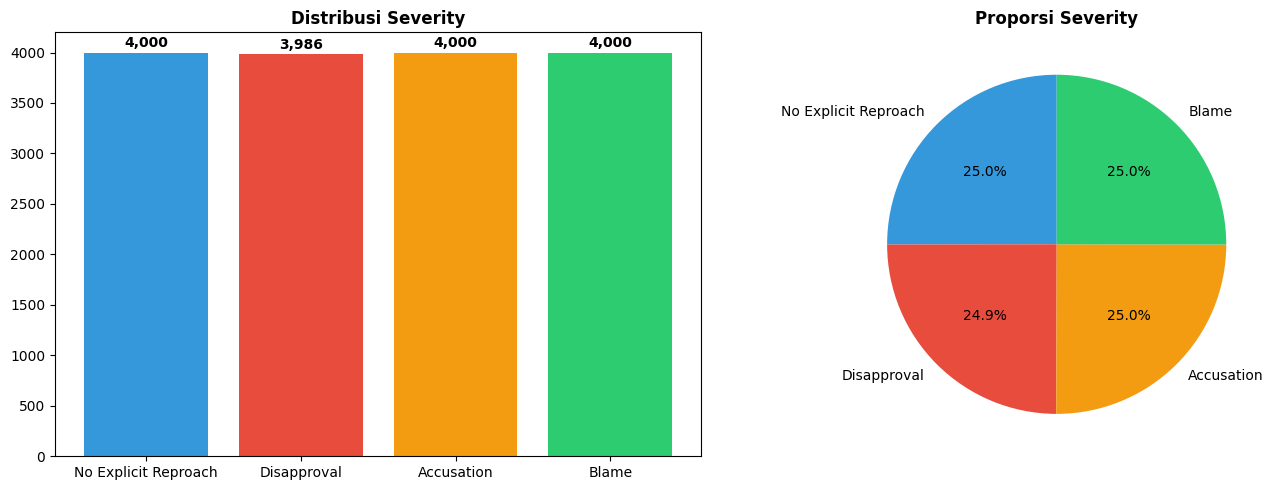

In [12]:
# Distribusi severity setelah preprocessing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = data['severity'].value_counts().sort_index()
colors = ['#3498db','#e74c3c','#f39c12','#2ecc71']

axes[0].bar([severity_names[i] for i in counts.index], counts.values, color=colors)
axes[0].set_title('Distribusi Severity', fontweight='bold')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+50, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=[severity_names[i] for i in counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporsi Severity', fontweight='bold')
plt.tight_layout(); plt.show()


In [13]:
# Statistik panjang teks bersih per severity
data['clean_len'] = data['clean_text'].apply(lambda x: len(x.split()))

stats = data.groupby('severity')['clean_len'].describe()
stats.index = [severity_names[i] for i in stats.index]
display(stats[['count','mean','min','max']].round(1))


,count,mean,min,max
No Explicit Reproach,4000.0,10.6,1.0,68.0
Disapproval,3986.0,6.7,1.0,133.0
Accusation,4000.0,18.2,1.0,58.0
Blame,4000.0,22.7,1.0,71.0


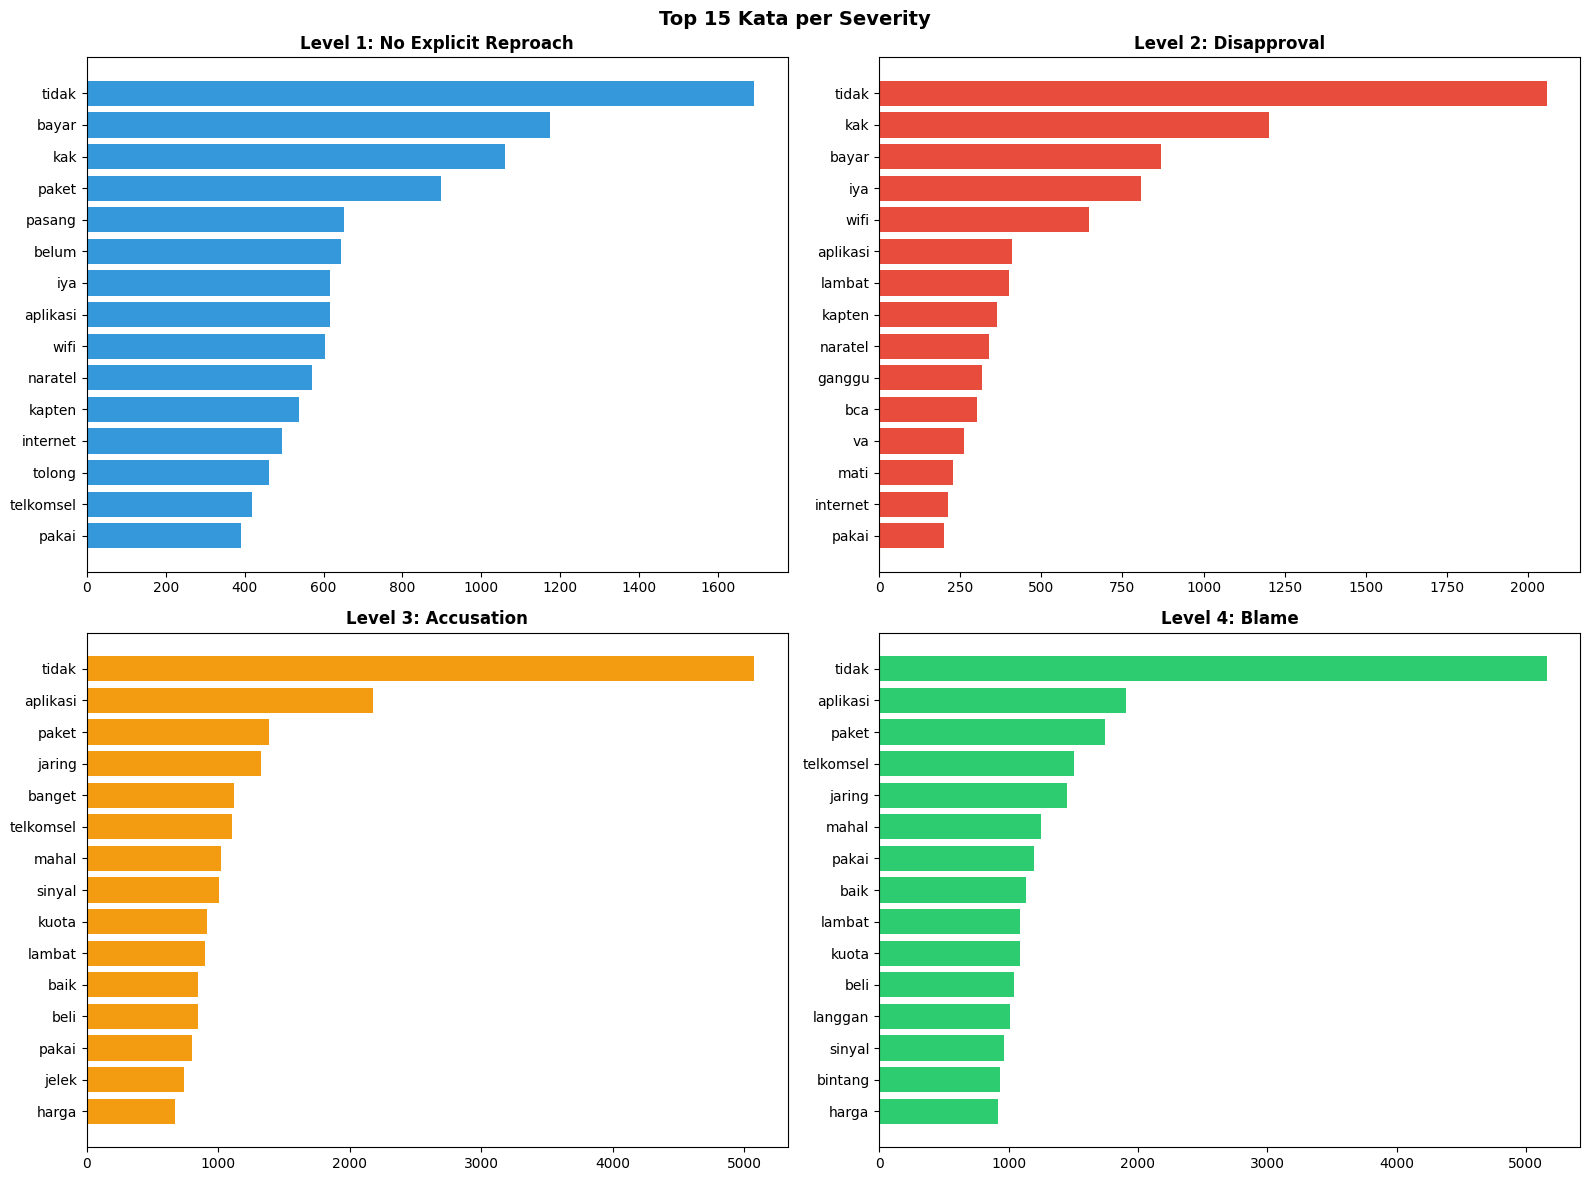

In [14]:
# Top 15 kata paling sering per severity (setelah preprocessing)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for idx, (level, name) in enumerate(severity_names.items()):
    ax = axes[idx//2][idx%2]
    words = ' '.join(data[data['severity']==level]['clean_text']).split()
    from collections import Counter
    top = Counter(words).most_common(15)
    ax.barh([w[0] for w in top][::-1], [w[1] for w in top][::-1], color=colors[idx])
    ax.set_title(f'Level {level}: {name}', fontweight='bold')
plt.suptitle('Top 15 Kata per Severity', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()


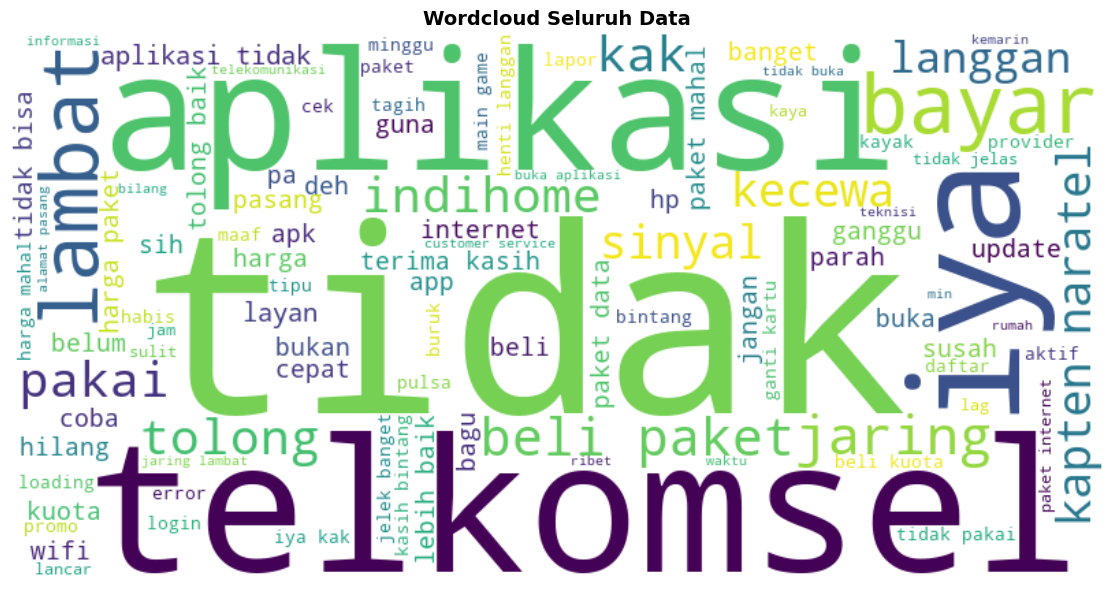

In [15]:
# Wordcloud untuk keseluruhan data yang telah diproses
all_words = ' '.join(data['clean_text'])
word_cloud = WordCloud(width=800, height=400, background_color='white',
                       colormap='viridis', max_words=100).generate(all_words)
plt.figure(figsize=(12, 6))
plt.imshow(word_cloud, interpolation='bilinear')
plt.title('Wordcloud Seluruh Data', fontweight='bold', fontsize=14)
plt.axis('off'); plt.tight_layout(); plt.show()


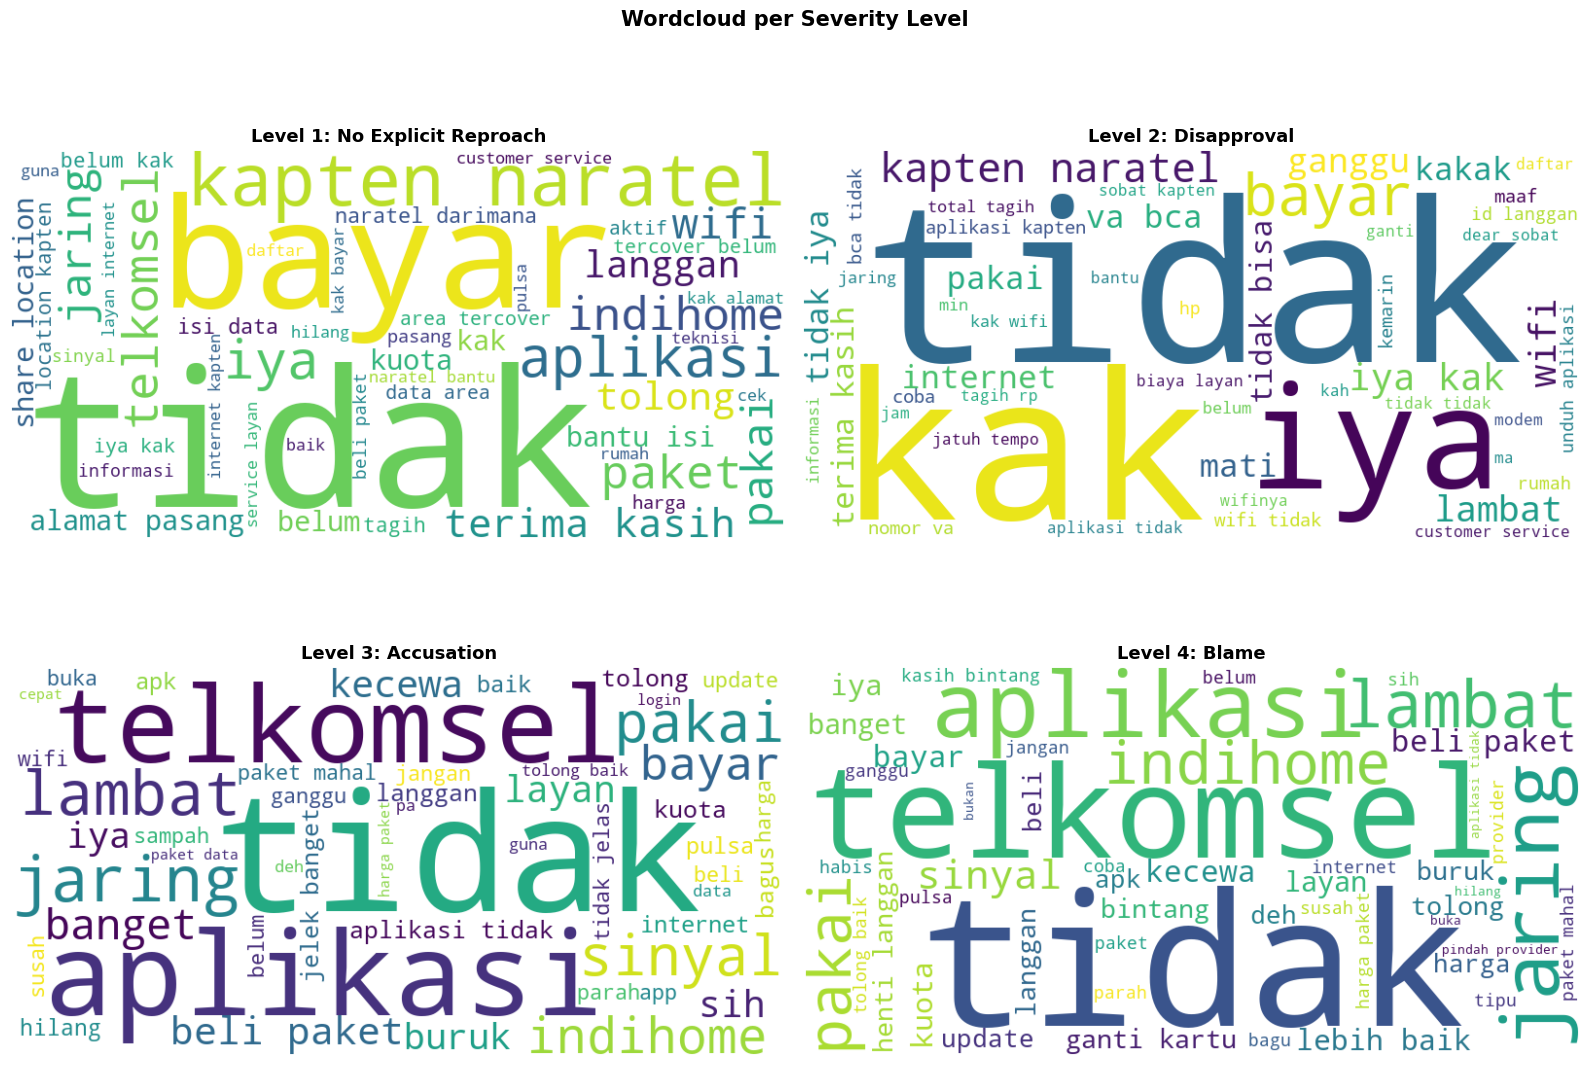

In [16]:
# Wordcloud per severity level
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for idx, (level, name) in enumerate(severity_names.items()):
    ax = axes[idx//2][idx%2]
    text = ' '.join(data[data['severity']==level]['clean_text'])
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap='viridis', max_words=50).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Level {level}: {name}', fontweight='bold', fontsize=13)
    ax.axis('off')
plt.suptitle('Wordcloud per Severity Level', fontweight='bold', fontsize=15)
plt.tight_layout(); plt.show()


# **5. FEATURE SELECTION / EXTRACTION**

In [17]:
# 1. Feature Extraction (TF-IDF) dengan Bigram
# Bigram menangkap frasa penting: "tidak bisa", "sangat buruk", dll
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2))
X = tfidf.fit_transform(data['clean_text']).toarray()
y = data['severity'].values
print(f'TF-IDF shape: {X.shape} (unigram + bigram)')
print(f'Jumlah fitur: {len(tfidf.get_feature_names_out())}')


TF-IDF shape: (15986, 8000) (unigram + bigram)
Jumlah fitur: 8000


In [18]:
# 2. Train-Test Split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training: {X_train.shape[0]:,} | Testing: {X_test.shape[0]:,}')


Training: 12,788 | Testing: 3,198


## **EVALUASI**

In [19]:
# Helper fungsi evaluasi dengan 10-Fold CV + Hold-Out
# Sesuai jurnal 822: "Evaluasi model menggunakan 10-Fold Cross Validation"
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def evaluasi_model(model, nama):
    # 10-Fold Cross Validation
    acc = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    prec = cross_val_score(model, X, y, cv=cv, scoring='precision_macro')
    rec = cross_val_score(model, X, y, cv=cv, scoring='recall_macro')
    f1 = cross_val_score(model, X, y, cv=cv, scoring='f1_macro')
    
    # Tabel per fold
    df_fold = pd.DataFrame({
        'Fold': [f'Fold {i+1}' for i in range(10)] + ['Mean', 'Std'],
        'Accuracy': [f'{v:.4f}' for v in acc] + [f'{acc.mean():.4f}', f'{acc.std():.4f}'],
        'Precision': [f'{v:.4f}' for v in prec] + [f'{prec.mean():.4f}', f'{prec.std():.4f}'],
        'Recall': [f'{v:.4f}' for v in rec] + [f'{rec.mean():.4f}', f'{rec.std():.4f}'],
        'F1-Score': [f'{v:.4f}' for v in f1] + [f'{f1.mean():.4f}', f'{f1.std():.4f}'],
    })
    print(f'===== 10-FOLD CROSS VALIDATION: {nama} =====')
    display(df_fold)
    
    # Grafik akurasi per fold
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(range(1,11), acc*100, 'bo-', linewidth=2, label='Accuracy per Fold')
    ax.axhline(y=acc.mean()*100, color='orange', linestyle='--', label=f'Mean: {acc.mean():.2%}')
    ax.fill_between(range(1,11), (acc.mean()-acc.std())*100, (acc.mean()+acc.std())*100, alpha=0.15, color='blue')
    ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{nama} — Akurasi per Fold', fontweight='bold')
    ax.set_xticks(range(1,11)); ax.legend(); plt.tight_layout(); plt.show()
    
    # Hold-Out Test
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f'\n===== HOLD-OUT TEST: {nama} =====')
    display(pd.DataFrame([{
        'Accuracy': f'{accuracy_score(y_test, y_pred):.4f}',
        'Precision': f'{precision_score(y_test, y_pred, average="macro", zero_division=0):.4f}',
        'Recall': f'{recall_score(y_test, y_pred, average="macro", zero_division=0):.4f}',
        'F1-Score': f'{f1_score(y_test, y_pred, average="macro", zero_division=0):.4f}',
    }]))
    print(classification_report(y_test, y_pred,
          target_names=[severity_names[i] for i in sorted(np.unique(y))], zero_division=0))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[severity_names[i] for i in sorted(np.unique(y))],
                yticklabels=[severity_names[i] for i in sorted(np.unique(y))], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {nama}', fontweight='bold')
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
    
    return model, y_pred, {'acc': accuracy_score(y_test, y_pred),
        'prec': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'rec': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'cv_acc': acc.mean(), 'cv_f1': f1.mean()}

print('Fungsi evaluasi siap. Menggunakan 10-Fold CV + Hold-Out Test.')


Fungsi evaluasi siap. Menggunakan 10-Fold CV + Hold-Out Test.


  alpha=0.01  -> CV Accuracy: 0.7171
  alpha=0.05  -> CV Accuracy: 0.7289
  alpha=0.1   -> CV Accuracy: 0.7348
  alpha=0.5   -> CV Accuracy: 0.7461
  alpha=1.0   -> CV Accuracy: 0.7460
  alpha=1.5   -> CV Accuracy: 0.7457
  alpha=2.0   -> CV Accuracy: 0.7460

Best alpha: 0.5
===== 10-FOLD CROSS VALIDATION: Multinomial NB (alpha=0.5) =====


,Fold,Accuracy,Precision,Recall,F1-Score
0,Fold 1,0.7405,0.7442,0.7405,0.7352
1,Fold 2,0.7386,0.7457,0.7386,0.7345
2,Fold 3,0.7523,0.7558,0.7524,0.7510
3,Fold 4,0.7398,0.7424,0.7399,0.7362
4,Fold 5,0.7492,0.7539,0.7493,0.7453
5,Fold 6,0.7536,0.7575,0.7536,0.7504
6,Fold 7,0.7353,0.7377,0.7354,0.7321
7,Fold 8,0.7547,0.7589,0.7548,0.7513
8,Fold 9,0.7685,0.7750,0.7686,0.7659
9,Fold 10,0.7534,0.7598,0.7535,0.7500


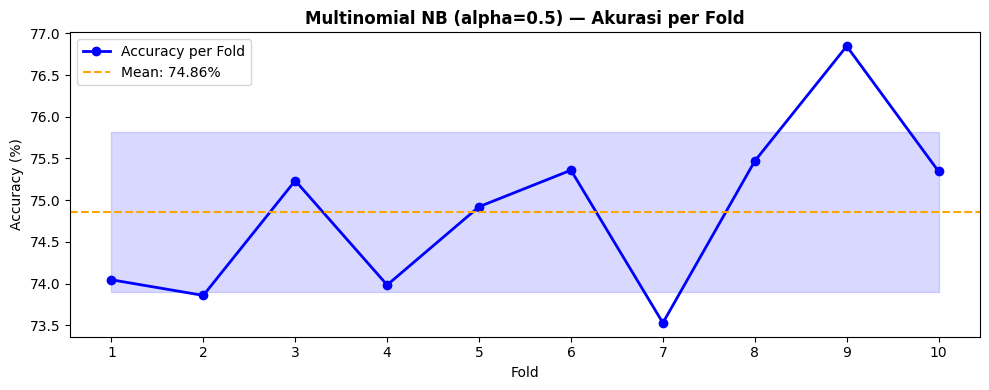


===== HOLD-OUT TEST: Multinomial NB (alpha=0.5) =====


,Accuracy,Precision,Recall,F1-Score
0,0.7373,0.7424,0.7374,0.7346


                      precision    recall  f1-score   support

No Explicit Reproach       0.79      0.58      0.67       800
         Disapproval       0.78      0.81      0.80       798
          Accusation       0.69      0.76      0.72       800
               Blame       0.71      0.80      0.75       800

            accuracy                           0.74      3198
           macro avg       0.74      0.74      0.73      3198
        weighted avg       0.74      0.74      0.73      3198



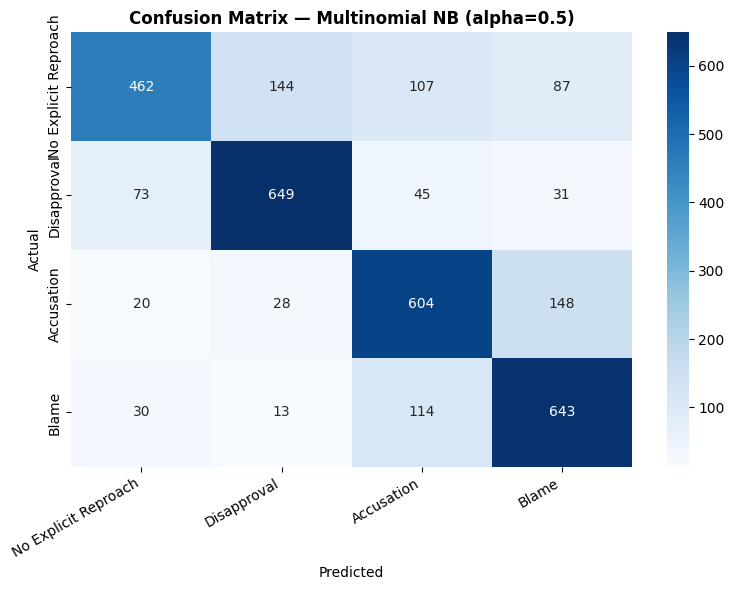

In [20]:
# 3. Multinomial Naive Bayes + Alpha Tuning
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 1.5, 2.0]
alpha_scores = []
for a in alphas:
    score = cross_val_score(MultinomialNB(alpha=a), X, y, cv=5, scoring='accuracy').mean()
    alpha_scores.append(score)
    print(f'  alpha={a:<5} -> CV Accuracy: {score:.4f}')

best_alpha = alphas[np.argmax(alpha_scores)]
print(f'\nBest alpha: {best_alpha}')

clf_nb, y_pred_nb, res_nb = evaluasi_model(
    MultinomialNB(alpha=best_alpha), f'Multinomial NB (alpha={best_alpha})')


===== 10-FOLD CROSS VALIDATION: Complement NB (alpha=0.5) =====


,Fold,Accuracy,Precision,Recall,F1-Score
0,Fold 1,0.7317,0.7329,0.7317,0.7261
1,Fold 2,0.7361,0.7400,0.7361,0.7307
2,Fold 3,0.7448,0.7475,0.7449,0.7423
3,Fold 4,0.7430,0.7450,0.7430,0.7393
4,Fold 5,0.7530,0.7581,0.7530,0.7481
5,Fold 6,0.7486,0.7495,0.7486,0.7449
6,Fold 7,0.7259,0.7266,0.7260,0.7219
7,Fold 8,0.7378,0.7389,0.7378,0.7335
8,Fold 9,0.7728,0.7778,0.7729,0.7698
9,Fold 10,0.7491,0.7570,0.7492,0.7445


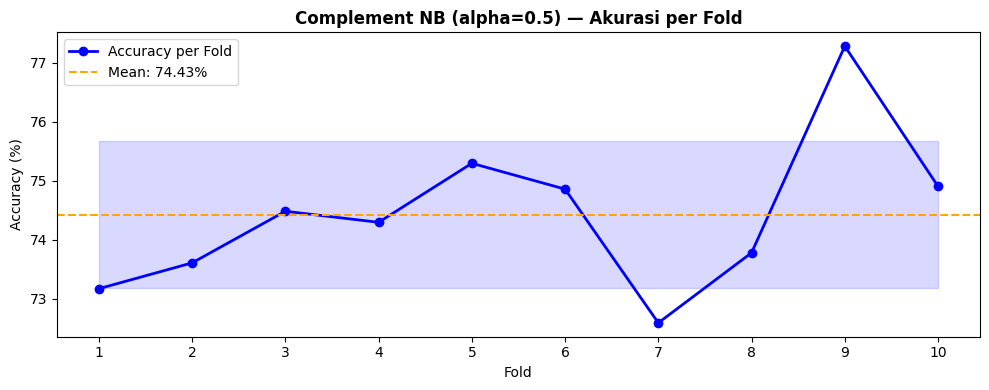


===== HOLD-OUT TEST: Complement NB (alpha=0.5) =====


,Accuracy,Precision,Recall,F1-Score
0,0.7361,0.7382,0.7361,0.7317


                      precision    recall  f1-score   support

No Explicit Reproach       0.75      0.56      0.64       800
         Disapproval       0.76      0.80      0.78       798
          Accusation       0.73      0.72      0.72       800
               Blame       0.71      0.86      0.78       800

            accuracy                           0.74      3198
           macro avg       0.74      0.74      0.73      3198
        weighted avg       0.74      0.74      0.73      3198



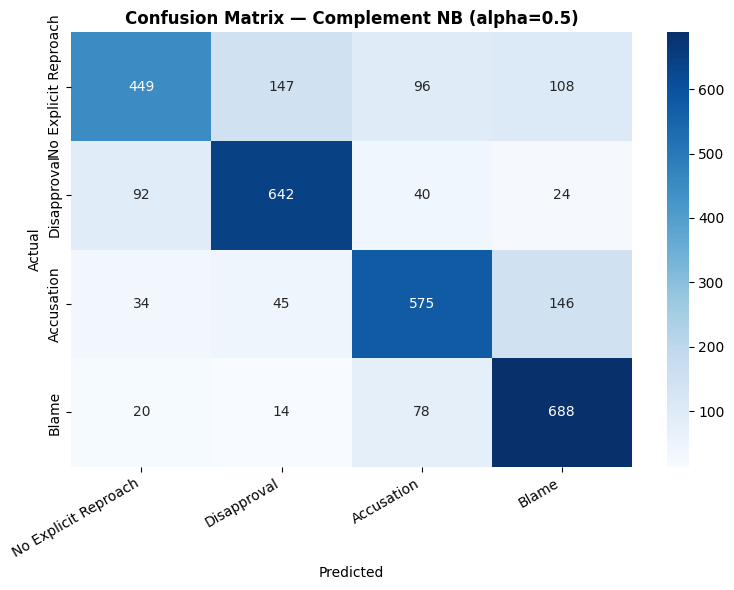

In [21]:
# 3b. Complement Naive Bayes
clf_cnb, y_pred_cnb, res_cnb = evaluasi_model(
    ComplementNB(alpha=best_alpha), f'Complement NB (alpha={best_alpha})')


## **KOMPARASI: Support Vector Machine (SVM)**

===== 10-FOLD CROSS VALIDATION: SVM Linear =====


,Fold,Accuracy,Precision,Recall,F1-Score
0,Fold 1,0.8493,0.8511,0.8493,0.8497
1,Fold 2,0.8512,0.8552,0.8512,0.8522
2,Fold 3,0.8580,0.8607,0.8580,0.8586
3,Fold 4,0.8305,0.8331,0.8305,0.8310
4,Fold 5,0.8518,0.8536,0.8518,0.8522
5,Fold 6,0.8549,0.8565,0.8549,0.8554
6,Fold 7,0.8404,0.8439,0.8404,0.8413
7,Fold 8,0.8504,0.8551,0.8504,0.8515
8,Fold 9,0.8592,0.8612,0.8592,0.8598
9,Fold 10,0.8573,0.8592,0.8573,0.8577


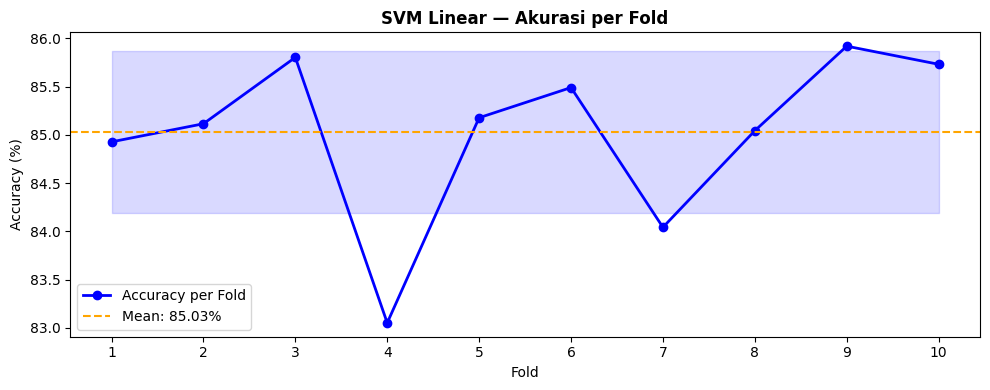


===== HOLD-OUT TEST: SVM Linear =====


,Accuracy,Precision,Recall,F1-Score
0,0.8427,0.8451,0.8427,0.8434


                      precision    recall  f1-score   support

No Explicit Reproach       0.78      0.83      0.80       800
         Disapproval       0.86      0.85      0.85       798
          Accusation       0.83      0.83      0.83       800
               Blame       0.91      0.86      0.89       800

            accuracy                           0.84      3198
           macro avg       0.85      0.84      0.84      3198
        weighted avg       0.85      0.84      0.84      3198



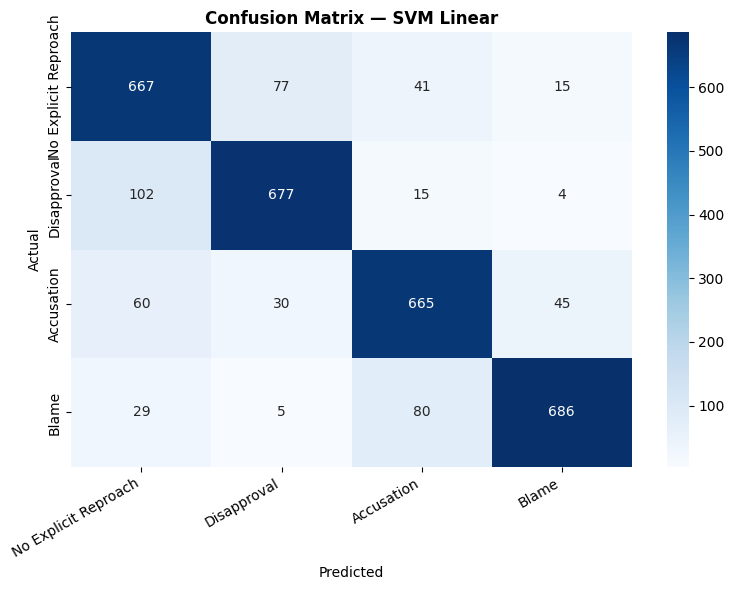

In [22]:
# 4. SVM Linear Kernel
clf_svm, y_pred_svm, res_svm = evaluasi_model(
    SVC(kernel='linear', C=1.0, random_state=42), 'SVM Linear')


===== 10-FOLD CROSS VALIDATION: SVM Polynomial (degree=3) =====


,Fold,Accuracy,Precision,Recall,F1-Score
0,Fold 1,0.7286,0.7386,0.7286,0.7287
1,Fold 2,0.7198,0.7315,0.7198,0.7203
2,Fold 3,0.7392,0.7503,0.7392,0.7405
3,Fold 4,0.7286,0.7368,0.7286,0.7297
4,Fold 5,0.7611,0.7691,0.7611,0.7616
5,Fold 6,0.7423,0.7514,0.7423,0.7425
6,Fold 7,0.7165,0.7256,0.7165,0.7175
7,Fold 8,0.7359,0.7457,0.7359,0.7351
8,Fold 9,0.7666,0.7765,0.7666,0.7675
9,Fold 10,0.7441,0.7553,0.7441,0.7449


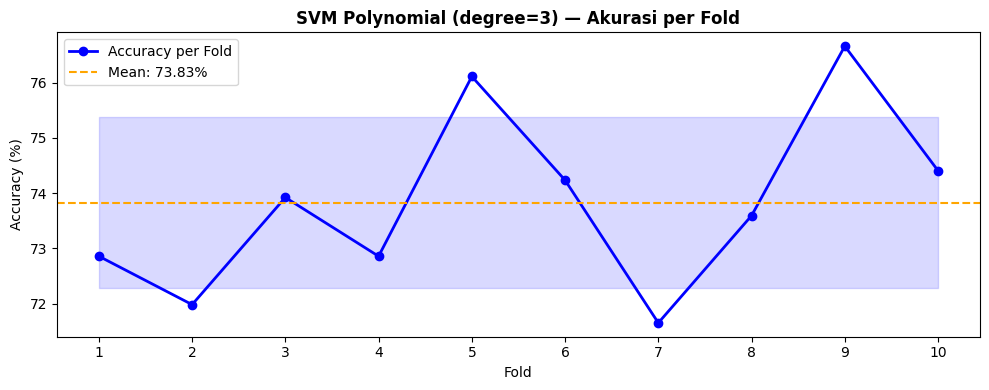


===== HOLD-OUT TEST: SVM Polynomial (degree=3) =====


,Accuracy,Precision,Recall,F1-Score
0,0.7248,0.7328,0.7248,0.7251


                      precision    recall  f1-score   support

No Explicit Reproach       0.74      0.63      0.68       800
         Disapproval       0.84      0.73      0.78       798
          Accusation       0.67      0.75      0.71       800
               Blame       0.69      0.79      0.73       800

            accuracy                           0.72      3198
           macro avg       0.73      0.72      0.73      3198
        weighted avg       0.73      0.72      0.73      3198



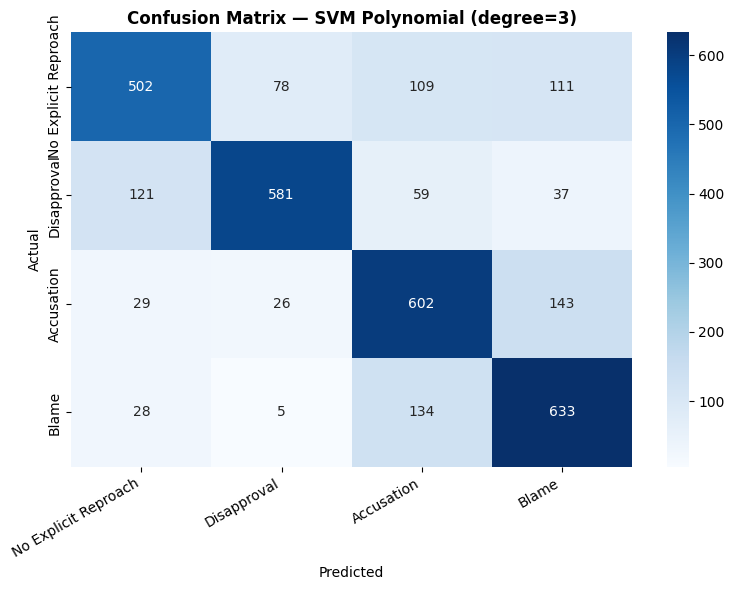

In [23]:
# 5. SVM Polynomial Kernel (degree=3)
clf_svm_poly, y_pred_svm_poly, res_poly = evaluasi_model(
    SVC(kernel='poly', degree=3, gamma='scale', random_state=42), 'SVM Polynomial (degree=3)')


===== 10-FOLD CROSS VALIDATION: SVM RBF =====


,Fold,Accuracy,Precision,Recall,F1-Score
0,Fold 1,0.8412,0.8428,0.8412,0.8417
1,Fold 2,0.8343,0.8381,0.8343,0.8352
2,Fold 3,0.8499,0.8541,0.8499,0.8509
3,Fold 4,0.8180,0.8206,0.8180,0.8187
4,Fold 5,0.8443,0.8473,0.8443,0.8450
5,Fold 6,0.8530,0.8558,0.8530,0.8537
6,Fold 7,0.8298,0.8348,0.8298,0.8310
7,Fold 8,0.8379,0.8426,0.8379,0.8391
8,Fold 9,0.8592,0.8614,0.8592,0.8598
9,Fold 10,0.8448,0.8488,0.8448,0.8454


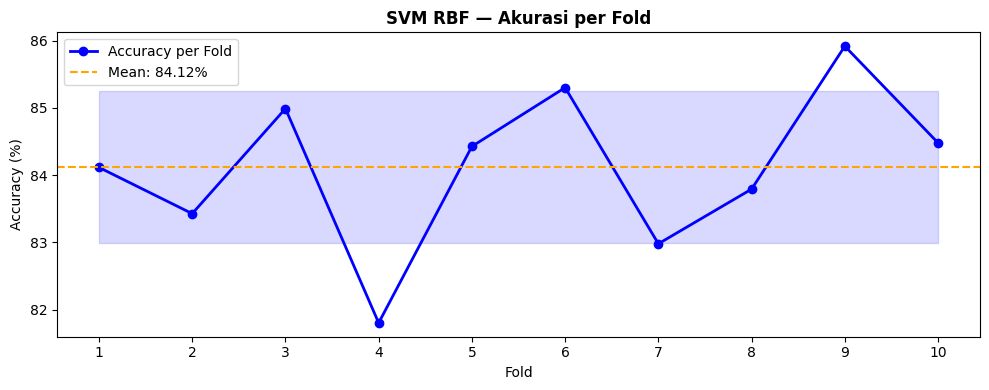


===== HOLD-OUT TEST: SVM RBF =====


,Accuracy,Precision,Recall,F1-Score
0,0.8393,0.8425,0.8393,0.8401


                      precision    recall  f1-score   support

No Explicit Reproach       0.78      0.85      0.81       800
         Disapproval       0.87      0.84      0.86       798
          Accusation       0.81      0.83      0.82       800
               Blame       0.91      0.84      0.87       800

            accuracy                           0.84      3198
           macro avg       0.84      0.84      0.84      3198
        weighted avg       0.84      0.84      0.84      3198



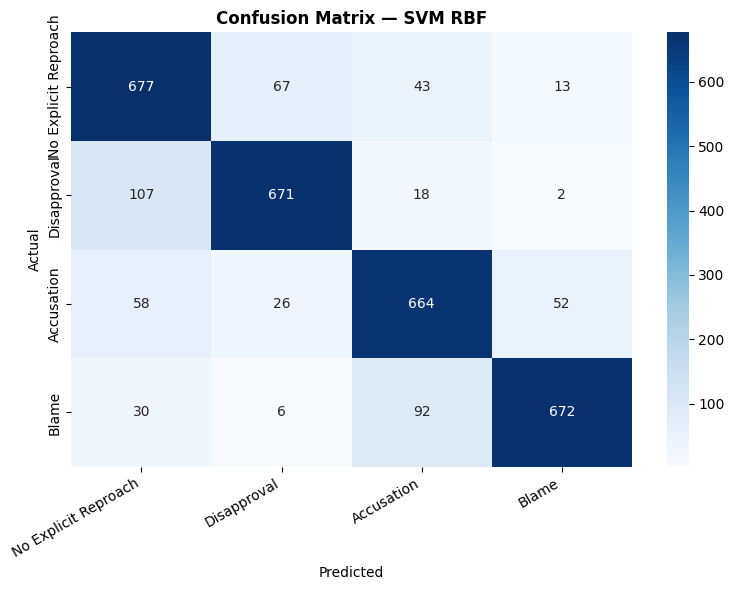

In [24]:
# 6. SVM RBF Kernel
clf_svm_rbf, y_pred_svm_rbf, res_rbf = evaluasi_model(
    SVC(kernel='rbf', gamma='scale', random_state=42), 'SVM RBF')


===== 10-FOLD CROSS VALIDATION: SVM Sigmoid =====


,Fold,Accuracy,Precision,Recall,F1-Score
0,Fold 1,0.8280,0.8298,0.8280,0.8284
1,Fold 2,0.8355,0.8385,0.8355,0.8363
2,Fold 3,0.8355,0.8388,0.8355,0.8361
3,Fold 4,0.8136,0.8159,0.8136,0.8140
4,Fold 5,0.8299,0.8323,0.8299,0.8305
5,Fold 6,0.8361,0.8387,0.8361,0.8368
6,Fold 7,0.8217,0.8261,0.8216,0.8226
7,Fold 8,0.8304,0.8355,0.8304,0.8313
8,Fold 9,0.8392,0.8423,0.8392,0.8400
9,Fold 10,0.8448,0.8475,0.8448,0.8453


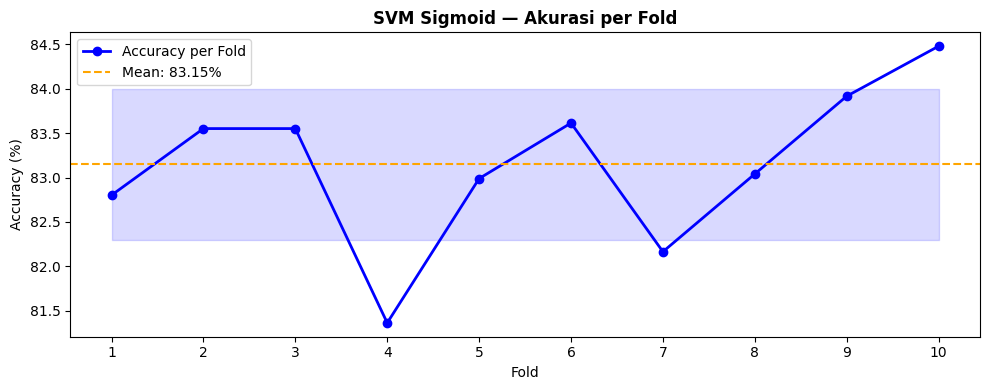


===== HOLD-OUT TEST: SVM Sigmoid =====


,Accuracy,Precision,Recall,F1-Score
0,0.8283,0.8313,0.8283,0.8291


                      precision    recall  f1-score   support

No Explicit Reproach       0.77      0.83      0.80       800
         Disapproval       0.83      0.81      0.82       798
          Accusation       0.80      0.82      0.81       800
               Blame       0.91      0.84      0.88       800

            accuracy                           0.83      3198
           macro avg       0.83      0.83      0.83      3198
        weighted avg       0.83      0.83      0.83      3198



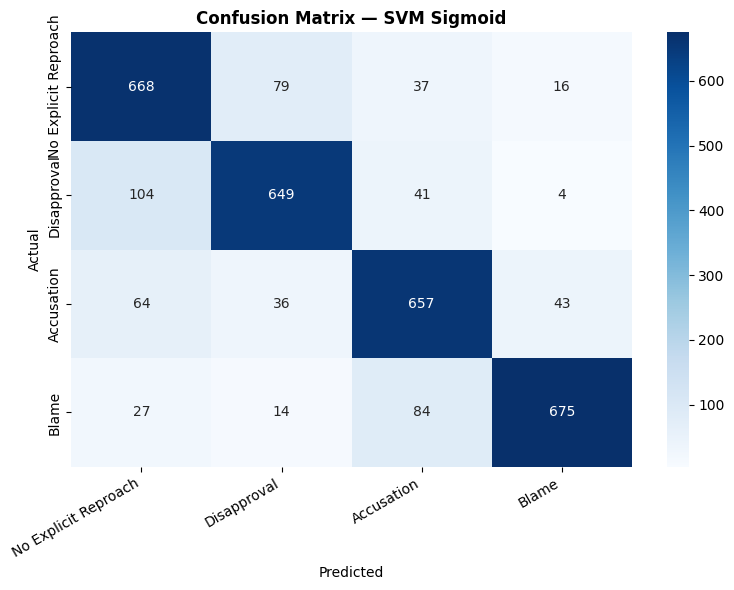

In [25]:
# 7. SVM Sigmoid Kernel
clf_svm_sig, y_pred_svm_sig, res_sig = evaluasi_model(
    SVC(kernel='sigmoid', gamma='scale', random_state=42), 'SVM Sigmoid')


## **PERBANDINGAN NAIVE BAYES vs SVM**

=== PERBANDINGAN SEMUA MODEL ===


,Model,10-Fold CV Acc,10-Fold CV F1,Hold-Out Acc,Precision,Recall,F1-Score
0,Multinomial NB,0.7486,0.7452,0.7373,0.7424,0.7374,0.7346
1,Complement NB,0.7443,0.7401,0.7361,0.7382,0.7361,0.7317
2,SVM Linear,0.8503,0.8510,0.8427,0.8451,0.8427,0.8434
3,SVM Poly,0.7383,0.7388,0.7248,0.7328,0.7248,0.7251
4,SVM RBF,0.8412,0.8420,0.8393,0.8425,0.8393,0.8401
5,SVM Sigmoid,0.8315,0.8321,0.8283,0.8313,0.8283,0.8291


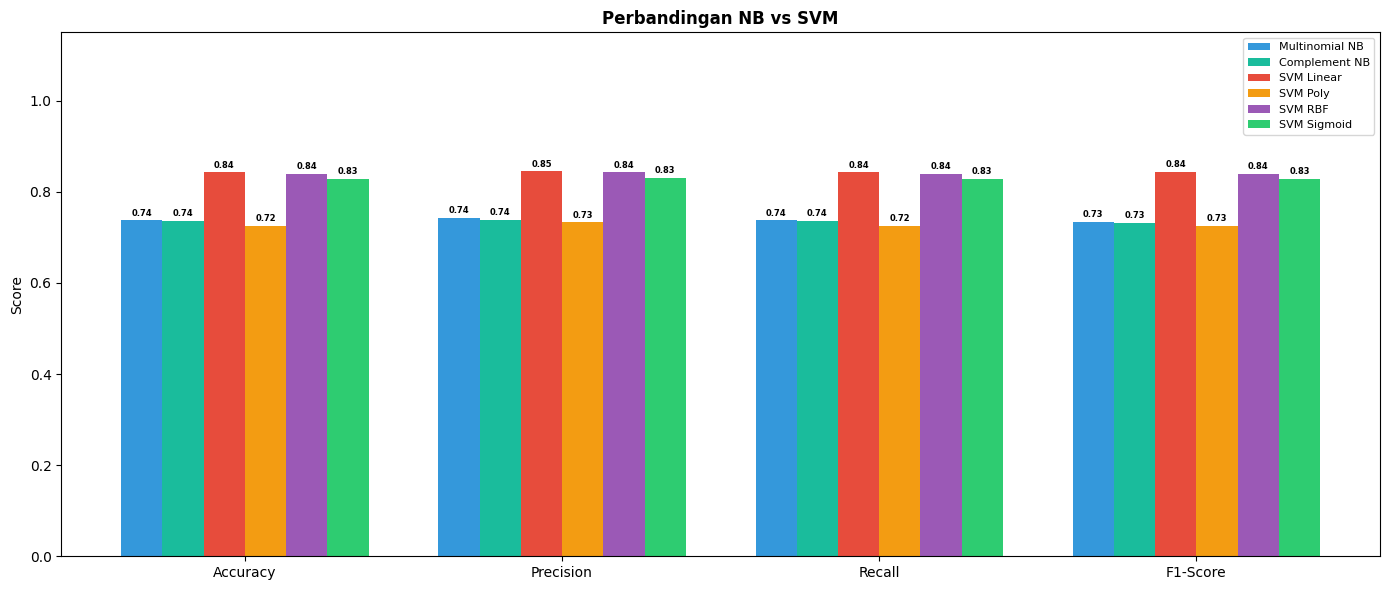

In [26]:
# Tabel Perbandingan Semua Model
all_results = {
    'Multinomial NB': res_nb, 'Complement NB': res_cnb,
    'SVM Linear': res_svm, 'SVM Poly': res_poly,
    'SVM RBF': res_rbf, 'SVM Sigmoid': res_sig
}

df_compare = pd.DataFrame([{
    'Model': name, '10-Fold CV Acc': f'{r["cv_acc"]:.4f}', '10-Fold CV F1': f'{r["cv_f1"]:.4f}',
    'Hold-Out Acc': f'{r["acc"]:.4f}', 'Precision': f'{r["prec"]:.4f}',
    'Recall': f'{r["rec"]:.4f}', 'F1-Score': f'{r["f1"]:.4f}'}
    for name, r in all_results.items()
])
print('=== PERBANDINGAN SEMUA MODEL ===')
display(df_compare)

# Visualisasi
models = list(all_results.keys())
metric_names = ['Accuracy','Precision','Recall','F1-Score']
clrs = ['#3498db','#1abc9c','#e74c3c','#f39c12','#9b59b6','#2ecc71']
x = np.arange(len(metric_names)); width = 0.13
fig, ax = plt.subplots(figsize=(14, 6))
for i, m in enumerate(models):
    vals = [all_results[m]['acc'], all_results[m]['prec'], all_results[m]['rec'], all_results[m]['f1']]
    bars = ax.bar(x + (i-len(models)/2+0.5)*width, vals, width, label=m, color=clrs[i])
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.2f}', ha='center', fontsize=6, fontweight='bold')
ax.set_ylabel('Score'); ax.set_title('Perbandingan NB vs SVM', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metric_names); ax.legend(fontsize=8); ax.set_ylim(0,1.15)
plt.tight_layout(); plt.show()


# **TEST MODEL & EXPORT PKL**

In [27]:
# Test prediksi teks baru dengan model terbaik (SVM Linear)
test_texts = [
    'internet saya lambat sekali sudah 3 hari tidak diperbaiki',
    'kapan wifi saya diperbaiki? sudah lapor berkali kali',
    'ISP kalian penipu, saya mau berhenti langganan',
    'maling uang rakyat, saya laporkan ke polisi',
    'tolong cek tagihan saya bulan ini',
    'sinyal hilang terus di daerah saya, kecewa berat',
]

def preprocess_single(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return ' '.join([cached_stem(w) for w in text.split()])

processed = [preprocess_single(t) for t in test_texts]
X_new = tfidf.transform(processed).toarray()
preds = clf_svm.predict(X_new)

display(pd.DataFrame({
    'Teks': test_texts,
    'Level': preds,
    'Severity': [severity_names.get(p, '?') for p in preds]
}))


,Teks,Level,Severity
0,internet saya lambat sekali sudah 3 hari tidak...,3,Accusation
1,kapan wifi saya diperbaiki? sudah lapor berkal...,3,Accusation
2,"ISP kalian penipu, saya mau berhenti langganan",4,Blame
3,"maling uang rakyat, saya laporkan ke polisi",3,Accusation
4,tolong cek tagihan saya bulan ini,1,No Explicit Reproach
5,"sinyal hilang terus di daerah saya, kecewa berat",3,Accusation


In [28]:
# Export TF-IDF Vectorizer
os.makedirs('../model', exist_ok=True)
with open('../model/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
size = os.path.getsize('../model/tfidf_vectorizer.pkl') / (1024*1024)
display(pd.DataFrame([{'File': 'tfidf_vectorizer.pkl', 'Ukuran': f'{size:.2f} MB', 'Keterangan': 'TF-IDF (8000 fitur, unigram+bigram)'}]))


,File,Ukuran,Keterangan
0,tfidf_vectorizer.pkl,0.30 MB,"TF-IDF (8000 fitur, unigram+bigram)"


In [29]:
# Export Multinomial Naive Bayes
with open('../model/multinomial_nb.pkl', 'wb') as f:
    pickle.dump(clf_nb, f)
size = os.path.getsize('../model/multinomial_nb.pkl') / (1024*1024)
display(pd.DataFrame([{'File': 'multinomial_nb.pkl', 'Ukuran': f'{size:.2f} MB', 'Parameter': f'alpha={best_alpha}', 'Accuracy': f'{res_nb["acc"]:.4f}'}]))


,File,Ukuran,Parameter,Accuracy
0,multinomial_nb.pkl,0.49 MB,alpha=0.5,0.7373


In [30]:
# Export SVM Linear
with open('../model/svm_linear.pkl', 'wb') as f:
    pickle.dump(clf_svm, f)
size = os.path.getsize('../model/svm_linear.pkl') / (1024*1024)
display(pd.DataFrame([{'File': 'svm_linear.pkl', 'Ukuran': f'{size:.2f} MB', 'Parameter': 'C=1.0, kernel=linear', 'Accuracy': f'{res_svm["acc"]:.4f}'}]))


,File,Ukuran,Parameter,Accuracy
0,svm_linear.pkl,506.63 MB,"C=1.0, kernel=linear",0.8427


In [31]:
# Export SVM Polynomial
with open('../model/svm_poly.pkl', 'wb') as f:
    pickle.dump(clf_svm_poly, f)
size = os.path.getsize('../model/svm_poly.pkl') / (1024*1024)
display(pd.DataFrame([{'File': 'svm_poly.pkl', 'Ukuran': f'{size:.2f} MB', 'Parameter': 'kernel=poly, degree=3', 'Accuracy': f'{res_poly["acc"]:.4f}'}]))


,File,Ukuran,Parameter,Accuracy
0,svm_poly.pkl,727.86 MB,"kernel=poly, degree=3",0.7248


In [32]:
# Export SVM RBF
with open('../model/svm_rbf.pkl', 'wb') as f:
    pickle.dump(clf_svm_rbf, f)
size = os.path.getsize('../model/svm_rbf.pkl') / (1024*1024)
display(pd.DataFrame([{'File': 'svm_rbf.pkl', 'Ukuran': f'{size:.2f} MB', 'Parameter': 'kernel=rbf, gamma=scale', 'Accuracy': f'{res_rbf["acc"]:.4f}'}]))


,File,Ukuran,Parameter,Accuracy
0,svm_rbf.pkl,642.49 MB,"kernel=rbf, gamma=scale",0.8393


In [33]:
# Export SVM Sigmoid
with open('../model/svm_sigmoid.pkl', 'wb') as f:
    pickle.dump(clf_svm_sig, f)
size = os.path.getsize('../model/svm_sigmoid.pkl') / (1024*1024)
display(pd.DataFrame([{'File': 'svm_sigmoid.pkl', 'Ukuran': f'{size:.2f} MB', 'Parameter': 'kernel=sigmoid, gamma=scale', 'Accuracy': f'{res_sig["acc"]:.4f}'}]))


,File,Ukuran,Parameter,Accuracy
0,svm_sigmoid.pkl,474.70 MB,"kernel=sigmoid, gamma=scale",0.8283


# **OUTPUT NLP**

In [34]:
# Terapkan prediksi ke seluruh dataset internal untuk dibawa ke model Decision Tree
df_internal = data[data['source']=='internal'].copy() if 'source' in data.columns else data.copy()
X_int = tfidf.transform(df_internal['clean_text']).toarray()
df_internal['predicted_severity'] = clf_svm.predict(X_int)

# Merge kode_user dan aggregasi per user
df_orig = pd.read_csv('../dataset/data_pesan_customer.csv')
df_result = df_internal[['message','clean_text','severity','predicted_severity']].merge(
    df_orig[['message','kode_user']], on='message', how='left')
df_result.dropna(subset=['kode_user'], inplace=True)

severity_per_user = df_result.groupby('kode_user')['predicted_severity'].max().reset_index()
print(f'User unik: {len(severity_per_user)}')
display(severity_per_user['predicted_severity'].value_counts().sort_index().to_frame('Jumlah User'))

# Simpan output
os.makedirs('../output', exist_ok=True)
df_result.to_csv('../output/data_with_severity.csv', index=False)
severity_per_user.to_csv('../output/severity_per_user.csv', index=False)
data.to_csv('../output/data_preprocessed.csv', index=False)

display(pd.DataFrame({
    'File': ['data_with_severity.csv', 'severity_per_user.csv', 'data_preprocessed.csv'],
    'Keterangan': ['Detail prediksi per pesan', 'Input Decision Tree (severity tertinggi per user)', 'Data lengkap setelah preprocessing']
}))


User unik: 1670


,Jumlah User
predicted_severity,
1,373
2,1155
3,38
4,104


,File,Keterangan
0,data_with_severity.csv,Detail prediksi per pesan
1,severity_per_user.csv,Input Decision Tree (severity tertinggi per user)
2,data_preprocessed.csv,Data lengkap setelah preprocessing
